<a href="https://colab.research.google.com/github/Wai-Fun/Healthcare-Data-Analytics/blob/main/Two_Sample_Hypothesis_Testing_and_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Evaluating Effectiveness of Two Treatments Using Hypothesis Testing**

##Overview
Hypothesis testing is the backbone of evaluating whether observed differences between treatment groups are likely due to an actual effect or random sampling variability.

##Objectives
- Formulate null and alternative hypotheses for clinical comparisons.
- Choose and run appropriate statistical tests (t-test, chi-square, Welch's t-test, Mann–Whitney) based on data type and assumptions.
- Check test assumptions (normality, variance equality, expected counts) and apply alternatives when assumptions fail.
- Interpret p-values, confidence intervals, and effect sizes to make evidence-based treatment decisions.
- Report results clearly for clinicians, including limitations and practical significance.


# The Dataset
- It's a randomized trial comparing Treatment A Vs Treatment B.
- The columns include: treatment, change_sbp, and event

# Tools:
- Python (panda, numpy, scipy, statsmodels, matplotlib, seaborn)



###0. Setup

Import Libraries

In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.stats.api as sms
from datetime import datetime, timedelta

# Reproducibility
np.random.seed(42)
pd.set_option('display.max_columns', 50)
sns.set(style='whitegrid')
print('Setup complete')

Setup complete


Create Dataset:

The code simulate a randomized two-group clinical trial dataset, generating systolic blood pressure change values and correlated binary event outcomes for two treatment groups.

In [50]:
def simulate_trial(n_per_group=80, effect_size=5.0, sd=12.0):
    # Treatment A baseline mean = 0, Treatment B mean = effect_size (difference)
    a = np.random.normal(loc=0.0, scale=sd, size=n_per_group)
    b = np.random.normal(loc=effect_size, scale=sd, size=n_per_group)
    df = pd.DataFrame({
        'treatment': ['A']*n_per_group + ['B']*n_per_group,
        'change_sbp': np.concatenate([a, b])
    })
    # Add a binary event outcome correlated with treatment for chi-square demo
    # Prob of event in A = 0.30, B = 0.18 (treatment reduces event)
    events_a = np.random.binomial(1, 0.30, size=n_per_group)
    events_b = np.random.binomial(1, 0.18, size=n_per_group)
    df['event'] = np.concatenate([events_a, events_b])
    return df

df = simulate_trial(n_per_group=90, effect_size=4.5, sd=13.0)
df.head()

,treatment,change_sbp,event
0,A,6.457284,0
1,A,-1.797436,1
2,A,8.419951,0
3,A,19.799388,0
4,A,-3.043994,0


###1. Inspect the Data

In [51]:
print('Rows, Columns:', df.shape)
print(df.dtypes)
df.describe().T

Rows, Columns: (180, 3)
treatment      object
change_sbp    float64
event           int64
dtype: object


,count,mean,std,min,25%,50%,75%,max
change_sbp,180.0,1.962163,12.734749,-34.056686,-6.576509,2.315537,9.781034,39.862199
event,180.0,0.266667,0.443450,0.000000,0.000000,0.000000,1.000000,1.000000


###2. Check Normality

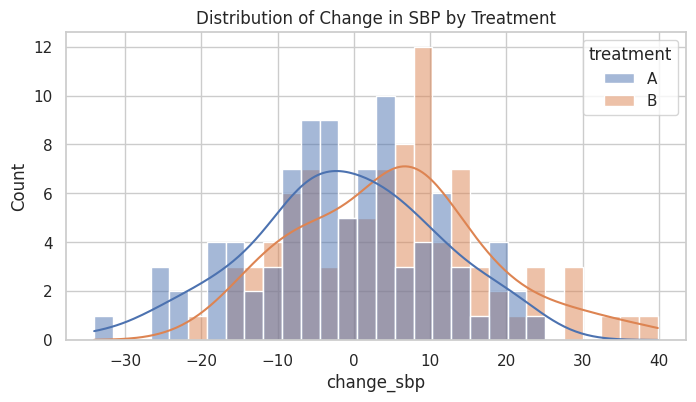

In [52]:
# Distribution and normality checks -to visually check if data is approx normally distributed
plt.figure(figsize=(8,4))
sns.histplot(data=df, x='change_sbp', hue='treatment', kde=True, bins=30)
plt.title('Distribution of Change in SBP by Treatment')
plt.show()

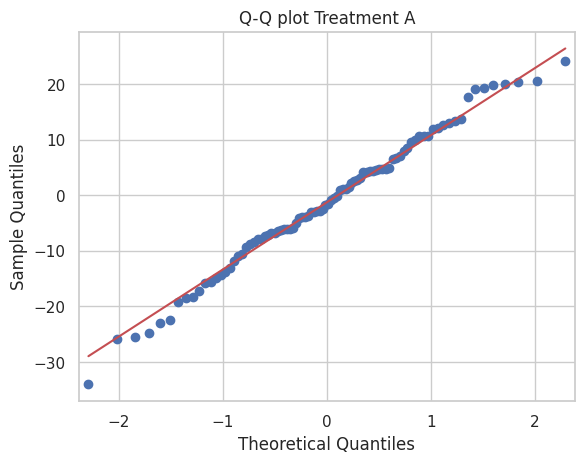

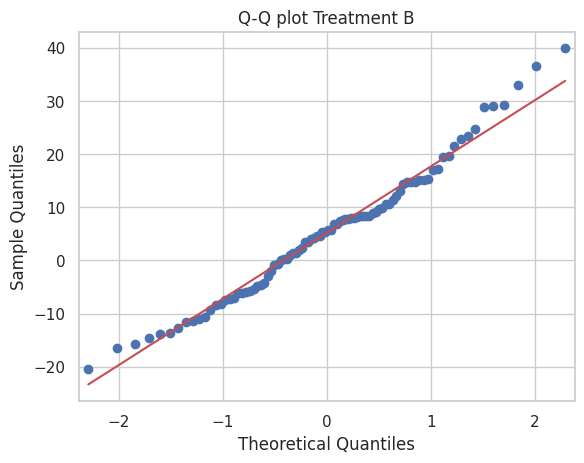

In [53]:
# Q-Q plots -- to visually check if data is approx normally distributed
import statsmodels.api as sm

sm.qqplot(df[df['treatment']=='A']['change_sbp'].dropna(), line='s')
plt.title('Q-Q plot Treatment A')
plt.show()
sm.qqplot(df[df['treatment']=='B']['change_sbp'].dropna(), line='s')
plt.title('Q-Q plot Treatment B')
plt.show()

In [54]:
# Shapiro-Wilk test - normality check (note: sensitive to sample size)
from scipy.stats import shapiro

def check_normality(data, name="data"):
    stat, p = shapiro(data.dropna())

    print(f"{name} - Shapiro p-value: {p:.4f}")

    if p >= 0.05:
        print("👉 Conclusion: Likely NORMAL distribution (fail to reject H0)\n")
    else:
        print("👉 Conclusion: NOT normal distribution (reject H0)\n")

# Check data normality by treatment group
check_normality(df[df['treatment'] == 'A']['change_sbp'], "Treatment A")
check_normality(df[df['treatment'] == 'B']['change_sbp'], "Treatment B")

Treatment A - Shapiro p-value: 0.6864
👉 Conclusion: Likely NORMAL distribution (fail to reject H0)

Treatment B - Shapiro p-value: 0.2135
👉 Conclusion: Likely NORMAL distribution (fail to reject H0)



###3. Check Equality of Variance

In [55]:
# Define Treatment Groups
group_a = df[df['treatment']=='A']['change_sbp'].dropna()
group_b = df[df['treatment']=='B']['change_sbp'].dropna()

# Levene's test for equal variances
lev_stat, lev_p = stats.levene(group_a, group_b)
print('Levene test for equal variances: stat=%.3f, p=%.4f' % (lev_stat, lev_p))

# Interpretation
alpha = 0.05  # significance level

if lev_p > alpha:
    print("Levene's test Result: Fail to reject H0 → Variances are equal (assumption met).")
else:
    print("Levene's test Result: Reject H0 → Variances are not equal (assumption violated).")

Levene test for equal variances: stat=0.005, p=0.9412
Levene's test Result: Fail to reject H0 → Variances are equal (assumption met).


###4. Two-sample test for Continuous data:
1. t-test
2. Welch's t-test
3. Mann-Whitney U

In [56]:
# Standard Student's t-test (assume equal variances).  -- this test should be selected
t_stat, p_val = stats.ttest_ind(group_a, group_b, equal_var=True)
print("Student's t-test: t=%.3f, p=%.4f" % (t_stat, p_val))

# Interpretation
alpha = 0.05  # significance level

if p_val > alpha:
    print("Student's t-test Result: Fail to reject H0 → No statistically significant difference between the two groups.")
else:
    print("Student's t-test Result: Reject H0 → There is a statistically significant difference between the two groups.")


Student's t-test: t=-3.528, p=0.0005
Student's t-test Result: Reject H0 → There is a statistically significant difference between the two groups.


In [57]:
# Welch's t-test (unequal variances)
t_stat_w, p_val_w = stats.ttest_ind(group_a, group_b, equal_var=False)
print("Welch's t-test: t=%.3f, p=%.4f" % (t_stat_w, p_val_w))

# Interpretation
alpha = 0.05  # significance level

if p_val > alpha:
    print("Welch's t-test Result: Fail to reject H0 → No statistically significant difference between the two groups.")
else:
    print("Welch's t-test Result: Reject H0 → There is a statistically significant difference between the two groups.")


Welch's t-test: t=-3.528, p=0.0005
Welch's t-test Result: Reject H0 → There is a statistically significant difference between the two groups.


In [58]:
# Mann-Whitney U test
u_stat, u_p = stats.mannwhitneyu(group_a, group_b, alternative='two-sided')
print('Mann-Whitney U: U=%.3f, p=%.4f' % (u_stat, u_p))

# Interpretation
alpha = 0.05  # significance level

if u_p > alpha:
    print("Mann-Whitney U Result: Fail to reject H0 → No significant difference in distributions between the two groups.")
else:
    print("Mann-Whitney U Result: Reject H0 → There is a significant difference in distributions between the two groups.")

Mann-Whitney U: U=2962.000, p=0.0019
Mann-Whitney U Result: Reject H0 → There is a significant difference in distributions between the two groups.


### 5. Two-sample test for Categorical Data
- Chi-square test

In [59]:
# Contingency table for event by treatment
ct = pd.crosstab(df['treatment'], df['event'])
ct.columns = ['no_event', 'event']
ct

# Chi-square test
chi2, chi_p, dof, expected = stats.chi2_contingency(ct)
print('Chi-square: chi2=%.3f, p=%.4f, dof=%d' % (chi2, chi_p, dof))
print('Expected counts matrix:\n', expected)

print('\n')

# Interpretation
if chi_p < 0.05:
    print("Chi-square result: Reject the null hypothesis. There is a statistically significant association between treatment and event.")
else:
    print("Chi-square result: Fail to reject the null hypothesis. No statistically significant association between treatment and event.")



Chi-square: chi2=3.438, p=0.0637, dof=1
Expected counts matrix:
 [[66. 24.]
 [66. 24.]]


Chi-square result: Fail to reject the null hypothesis. No statistically significant association between treatment and event.


###6. Effect Sizes and Confidence Intervals

In [60]:
# Cohen's test for effect size
# Cohen's d interpretation (rule of thumb)
def interpret_cohens_d(d):
    d_abs = abs(d)

    if d_abs < 0.2:
        return "negligible effect"
    elif d_abs < 0.5:
        return "small effect"
    elif d_abs < 0.8:
        return "medium effect"
    else:
        return "large effect"

# Cohen's d for independent groups (pooled)
def cohens_d(x, y):
    nx = len(x); ny = len(y)
    dof = nx + ny - 2
    pooled_sd = np.sqrt(((nx-1)*np.nanvar(x, ddof=1) + (ny-1)*np.nanvar(y, ddof=1)) / dof)
    return (np.nanmean(y) - np.nanmean(x)) / pooled_sd

d = cohens_d(group_a, group_b)
print("Cohen's d (B vs A):", round(d,3))

# Interpretation
effect = interpret_cohens_d(d)

direction = "higher in B than A" if d > 0 else "lower in B than A" if d < 0 else "no difference"

print(f"Cohen's test result: The effect size is {effect}, with values {direction}.")


Cohen's d (B vs A): 0.526
Cohen's test result: The effect size is medium effect, with values higher in B than A.


In [61]:
# 95% CI for difference in means using statsmodels
cm = sms.CompareMeans(sms.DescrStatsW(group_b), sms.DescrStatsW(group_a))
ci_low, ci_upp = cm.tconfint_diff(usevar='unequal')

print('95% CI for mean difference (B-A):', (ci_low, ci_upp))

# Interpretation
if ci_low > 0:
    print("Interpretation: The mean of group B is significantly higher than group A (95% CI does not include 0).")
elif ci_upp < 0:
    print("Interpretation: The mean of group B is significantly lower than group A (95% CI does not include 0).")
else:
    print("Interpretation: No statistically significant difference between groups (95% CI includes 0).")

95% CI for mean difference (B-A): (np.float64(2.8614181760407233), np.float64(10.12526125825369))
Interpretation: The mean of group B is significantly higher than group A (95% CI does not include 0).


###7. Reporting and interpretation


In [62]:
# Programmatic reporting
mean_a = group_a.mean()
mean_b = group_b.mean()
print(f"Mean change SBP - Treatment A: {mean_a:.2f}")
print(f"Mean change SBP - Treatment B: {mean_b:.2f}")
print(f"Mean difference (B-A): {mean_b-mean_a:.2f}")
print(f"p-value (Student t-test): {p_val}")
print(f"Cohen's d: {d:.3f}")

# Simple interpretation helper
if p_val< 0.05:
    print('\nInterpretation: Statistically significant difference between treatments (p<0.05).')
else:
    print('\nInterpretation: No statistically significant difference detected.')

Mean change SBP - Treatment A: -1.28
Mean change SBP - Treatment B: 5.21
Mean difference (B-A): 6.49
p-value (Student t-test): 0.0005325109729784289
Cohen's d: 0.526

Interpretation: Statistically significant difference between treatments (p<0.05).


**Disclaimer:**

This project was completed as part of the course “Statistical Analysis and Data Modeling in Healthcare.” The core structure and concepts are based on the course materials. The analysis has been reorganized for clarity, with additional code and extensions added to improve interpretation and understanding of results. The code has also been made more modular and reusable to support future projects and real-world analytical applications. As a result, the final work may differ in structure and flow from the original course content.

**End of Project**